In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()

In [4]:
cwpd = pd.read_csv('data/Citywide_Payroll_Data_(Fiscal_Year)_20260414.csv')
cwpd_raw = cwpd.copy()

/var/folders/rf/8gv1whtd1h372v3h09816xg80000gn/T/ipykernel_1845/677125487.py:1: DtypeWarning: Columns (7,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  cwpd = pd.read_csv('data/Citywide_Payroll_Data_(Fiscal_Year)_20260414.csv')


In [5]:
for c in ["Base Salary", "Regular Hours", "Regular Gross Paid", "OT Hours", "Total OT Paid", "Total Other Pay"]:
    cwpd[c] = cwpd[c].replace("[$,]","", regex=True).apply(pd.to_numeric)

In [6]:
cwpd["Work Location Borough"] = cwpd["Work Location Borough"].str.upper()
cwpd = cwpd[cwpd["Work Location Borough"].isin(['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'RICHMOND'])]

In [7]:
cwpd = cwpd[cwpd["Regular Hours"] >= 0]
cwpd = cwpd[cwpd["Regular Gross Paid"] > 0]

In [8]:
cwpd[cwpd["Pay Basis"] == "per Annum"]["Regular Gross Paid"].mean()

np.float64(69112.97463266365)

In [9]:
print(os.path.getsize("Citywide_Payroll_Data_(Fiscal_Year)_20260414.csv") / 1000000)
print(len(cwpd_raw))

FileNotFoundError: [Errno 2] No such file or directory: 'Citywide_Payroll_Data_(Fiscal_Year)_20260414.csv'

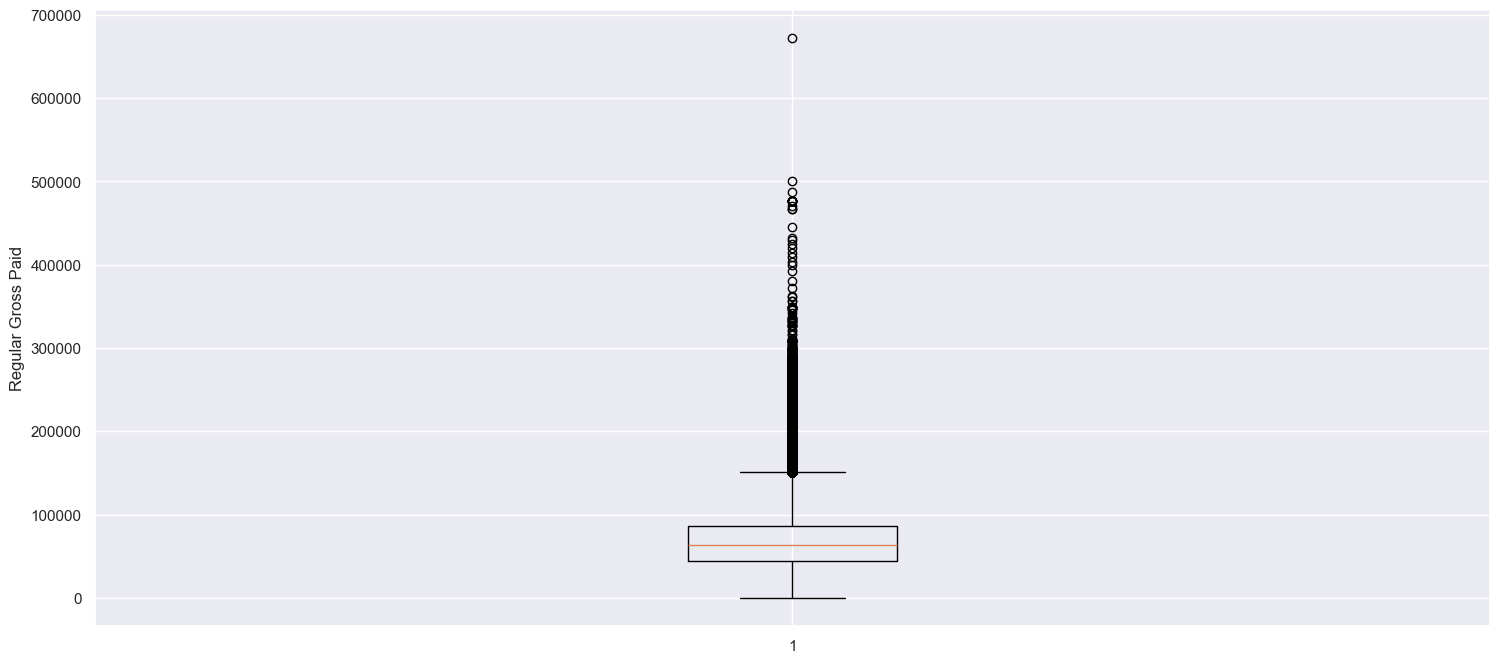

In [ ]:
plt.figure(figsize=(18, 8))

plt.boxplot(cwpd[cwpd["Pay Basis"] == "per Annum"]["Regular Gross Paid"])
# plt.xticks(range(1, len(pfc_list) + 1), pfc_list, rotation=45)
plt.ylabel("Regular Gross Paid")
plt.show()

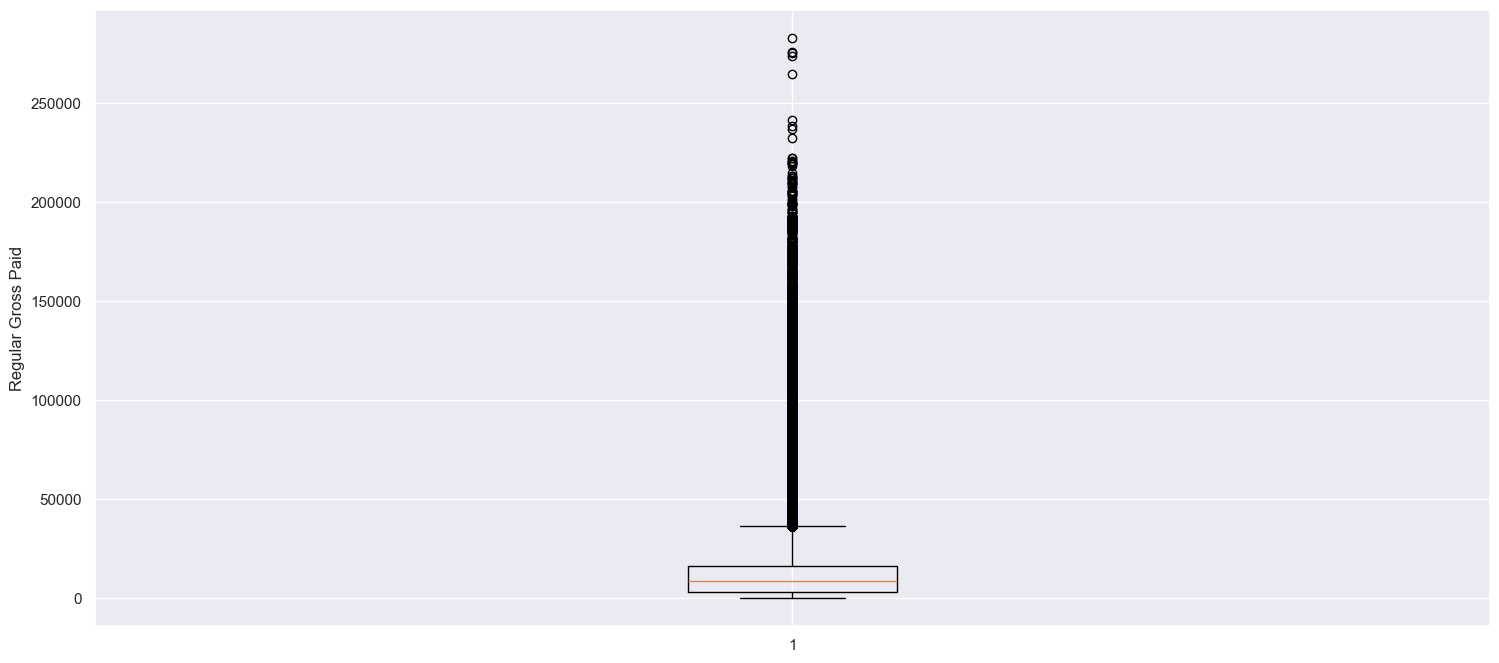

In [ ]:
plt.figure(figsize=(18, 8))

plt.boxplot(cwpd[cwpd["Pay Basis"] == "per Hour"]["Regular Gross Paid"])
# plt.xticks(range(1, len(pfc_list) + 1), pfc_list, rotation=45)
plt.ylabel("Regular Gross Paid")
plt.show()

In [ ]:
cwpd["Work Location Borough"].unique()

array(['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'RICHMOND'],
      dtype=object)

In [ ]:
cwpd["Work Location Borough"].value_counts()

Work Location Borough
MANHATTAN    1048300
QUEENS        641018
BROOKLYN      536278
BRONX         296267
RICHMOND       80603
Name: count, dtype: int64

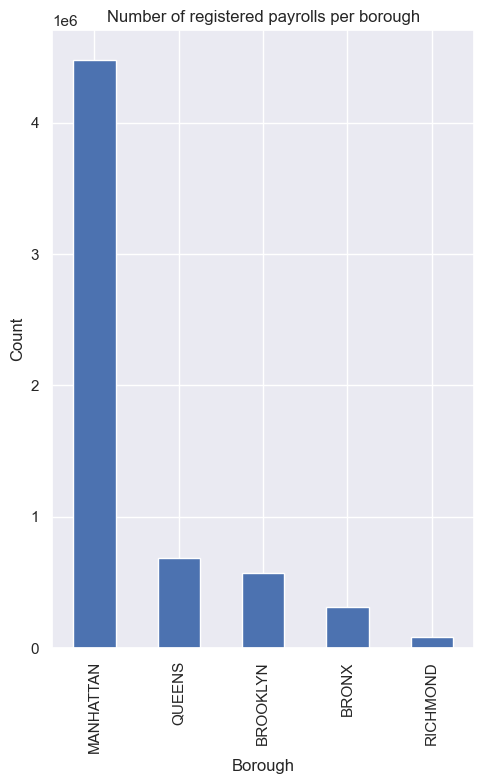

In [ ]:
plt.figure(figsize=(5, 8))
# cwpd["Work Location Borough"].value_counts().plot(kind='bar')
cwpd_raw[cwpd_raw["Work Location Borough"].isin(['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'RICHMOND'])]["Work Location Borough"].value_counts().plot(kind='bar')
plt.xlabel("Borough")
plt.ylabel("Count")
plt.title("Number of registered payrolls per borough")
plt.tight_layout()
plt.show()

In [ ]:
cwpd.head()

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
1,2025,67.0,ADMIN FOR CHILDREN'S SVCS,BRAY,TONI,J,01/05/2015,MANHATTAN,CHILD PROTECTIVE SPECIALIST,ACTIVE,70106.0,per Annum,1820.0,67939.88,0.00,0.00,6102.31
2,2025,67.0,ADMIN FOR CHILDREN'S SVCS,HILL,BRYNETTA,K,01/05/2015,BROOKLYN,CHILD PROTECTIVE SPECIALIST,ACTIVE,70106.0,per Annum,1820.0,67939.88,35.50,1394.74,6158.16
3,2025,67.0,ADMIN FOR CHILDREN'S SVCS,ADENUGA,ADEOLA,T,01/05/2015,MANHATTAN,CHILD PROTECTIVE SPECIALIST SUPERVISOR,ACTIVE,100050.0,per Annum,1820.0,100477.11,34.75,2150.26,6188.40
5,2025,67.0,ADMIN FOR CHILDREN'S SVCS,RIOS,NANCY,NaN,01/05/2015,MANHATTAN,COMMUNITY COORDINATOR,ACTIVE,74861.0,per Annum,1820.0,72548.41,0.00,0.00,8.25
6,2025,67.0,ADMIN FOR CHILDREN'S SVCS,PYATETSKAYA,TAMARA,NaN,01/05/2015,MANHATTAN,CHILD PROTECTIVE SPECIALIST,ACTIVE,79230.0,per Annum,1820.0,71670.29,0.00,0.00,5983.30


In [ ]:
cwpd["Pay Basis"].unique()

array(['per Annum', 'per Day', 'per Hour', 'Prorated Annual'],
      dtype=object)

In [ ]:
# cwpd_0_reg_hours = cwpd[cwpd["Regular Hours"] == 0]

In [ ]:
cwpd = cwpd[cwpd["Regular Hours"] > 0]

In [ ]:
cwpd["Hourly Rate"] = cwpd["Regular Gross Paid"] / cwpd["Regular Hours"]
cwpd["Annual Salary Estimate"] = cwpd["Hourly Rate"] * 52 * 5 * 8 # Working 8 hours/day, 5 days/week, 52 weeks/year

/var/folders/rf/8gv1whtd1h372v3h09816xg80000gn/T/ipykernel_38961/1262441695.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cwpd["Hourly Rate"] = cwpd["Regular Gross Paid"] / cwpd["Regular Hours"]
/var/folders/rf/8gv1whtd1h372v3h09816xg80000gn/T/ipykernel_38961/1262441695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cwpd["Annual Salary Estimate"] = cwpd["Hourly Rate"] * 52 * 5 * 8 # Working 8 hours/day, 5 days/week, 52 weeks/year


In [ ]:
cwpd[(cwpd["Regular Hours"] > 1000) & (cwpd["Annual Salary Estimate"] > 20000)][["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").describe()
# cwpd[(cwpd["Regular Hours"] > 1000)]

Annual Salary Estimate                                            \
                             count          mean           std           min   
Fiscal Year                                                                    
2014                        2789.0  78737.902938  41616.127363  26237.863957   
2015                      178636.0  69576.547054  29271.379983  20000.008481   
2016                      181993.0  72217.480854  30771.574140  20009.227872   
2017                      188301.0  76456.850501  31947.016783  20160.139616   
2018                      190831.0  75557.099335  32089.622784  20302.288706   
2019                      192871.0  76852.377715  32320.093594  20496.687040   
2020                      196203.0  77103.883370  32422.385182  20083.337143   
2021                      191282.0  79010.030297  33382.965772  20012.490000   
2022                      184492.0  81988.495307  35289.367957  20005.638095   
2023                      178920.0  83099.960655  35118.150666  20004.526829   
2024                      181857.0  95431.013300  43358.018390  20118.984167   
2025                      181048.0  93024.356641  39736.674983  20072.036017   

                                                                       
                      25%           50%            75%            max  
Fiscal Year                                                            
2014         47607.883397  68890.853699   92991.373722  337294.113684  
2015         46320.350449  68883.729743   80737.865036  530067.033155  
2016         47333.679892  69144.814863   88268.412466  764154.332678  
2017         50861.743391  72869.329344   96413.028570  413054.993534  
2018         49721.840301  72914.214078   89073.241417  554602.158578  
2019         51248.576415  74403.516863   91120.092325  646597.116031  
2020         51498.771429  74547.390000   91940.160000  468062.413506  
2021         52658.080000  76281.610000   93558.400000  472592.057143  
2022         52296.180443  79555.961405  102760.414596  472652.365714  
2023         55008.068571  82608.708571  100166.810000  467495.291429  
2024         59786.921739  87527.428571  120703.540000  822203.694257  
2025         59428.340000  89543.840000  112317.188036  448491.782857

In [ ]:
cwpd[["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").describe()

Annual Salary Estimate                                             \
                             count           mean            std          min   
Fiscal Year                                                                     
2014                        3172.0   78597.817112   54344.418952  2080.000000   
2015                      230772.0   80743.323554  424377.375287     2.275089   
2016                      238842.0   83654.681725  451503.742735     4.333333   
2017                      245520.0   92417.777219  434867.165856    90.962099   
2018                      246946.0   89101.231514  454597.692489     0.520000   
2019                      248384.0   88277.872952  373513.061979   249.600000   
2020                      245262.0   88744.064110  421460.106983     0.037143   
2021                      227491.0   91954.188702  370973.092870     0.028889   
2022                      233726.0   94196.818960  381524.439422     0.027013   
2023                      229765.0   96231.691764  408849.544928     0.780000   
2024                      226178.0  111003.130928  528577.919281    28.161446   
2025                      226408.0  106828.303076  499452.821186     0.495238   

                                                                      
                      25%           50%            75%           max  
Fiscal Year                                                           
2014         46886.137644  68724.032000   92133.776867  1.897297e+06  
2015         42187.600000  64976.184804   82577.043245  5.489282e+07  
2016         42827.846164  63803.744262   89428.652303  1.187965e+08  
2017         46368.704479  69429.107624   97903.329475  6.127806e+07  
2018         45933.569609  68227.764916   90164.216892  7.743273e+07  
2019         47522.810196  70325.833957   93339.819384  6.173920e+07  
2020         48163.248571  72201.240000   94063.697267  8.861402e+07  
2021         50060.948571  75460.900000   96857.000000  6.193949e+07  
2022         49509.530446  76009.350723  104069.531429  6.199411e+07  
2023         50095.500000  79291.200000  101204.350000  6.193949e+07  
2024         55586.920598  85002.278099  122251.584720  1.200237e+08  
2025         56784.040589  85822.526259  113279.080000  7.108253e+07

In [ ]:
cwpd[["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean()['Annual Salary Estimate']

Fiscal Year
2014     78597.817112
2015     80743.323554
2016     83654.681725
2017     92417.777219
2018     89101.231514
2019     88277.872952
2020     88744.064110
2021     91954.188702
2022     94196.818960
2023     96231.691764
2024    111003.130928
2025    106828.303076
Name: Annual Salary Estimate, dtype: float64

In [ ]:
cwpd["Fiscal Year"].unique()[::-1]

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025])

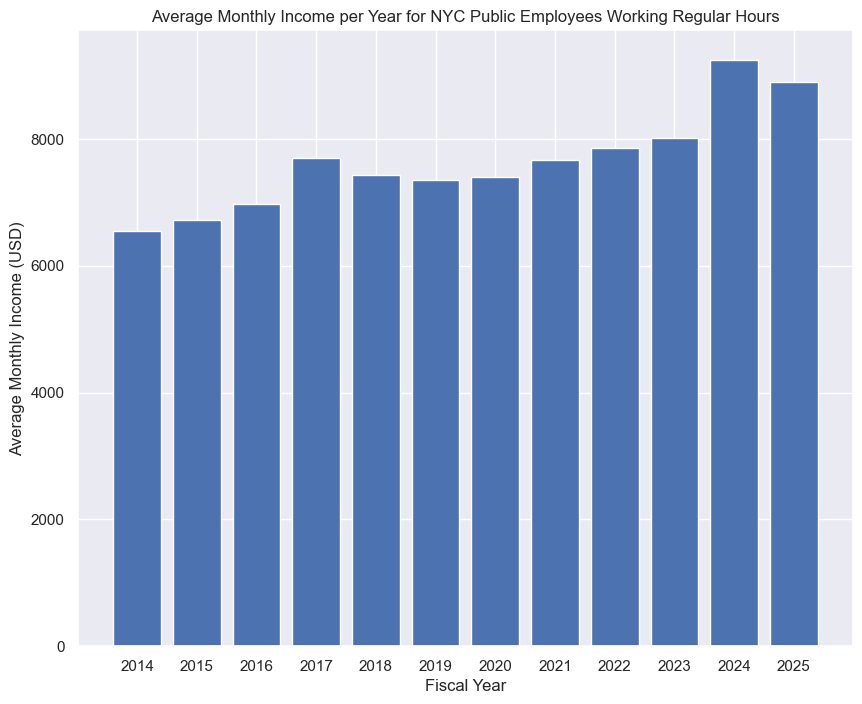

In [ ]:
plt.figure(figsize=(10, 8))
plt.bar(cwpd["Fiscal Year"].unique()[::-1], cwpd[["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean()['Annual Salary Estimate'] / 12);
plt.xticks(cwpd["Fiscal Year"].unique()[::-1]);
plt.title("Average Monthly Income per Year for NYC Public Employees Working Regular Hours");
plt.ylabel("Average Monthly Income (USD)");
plt.xlabel("Fiscal Year");

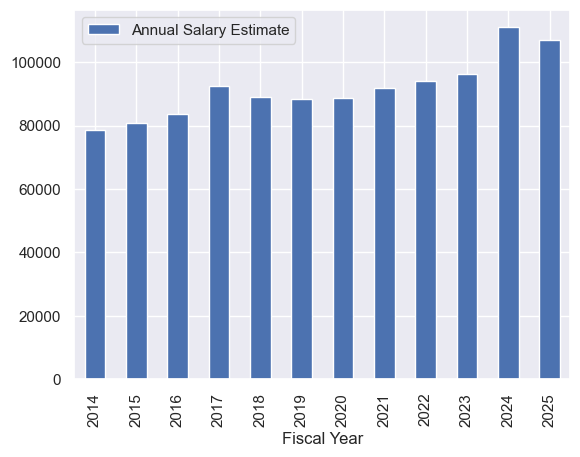

In [ ]:
cwpd[["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean().plot(kind='bar');

In [ ]:
cwpd[["Fiscal Year", "Annual Salary Estimate", "Work Location Borough"]].groupby(["Work Location Borough", "Fiscal Year"]).mean()['Annual Salary Estimate'] / 12

Work Location Borough  Fiscal Year
BRONX                  2014            5886.634866
                       2015            6585.016167
                       2016            6797.213037
                       2017            7721.002474
                       2018            6991.598113
                       2019            6677.108964
                       2020            6336.037294
                       2021            6751.953333
                       2022            6966.632931
                       2023            6736.178710
                       2024            7660.853681
                       2025            7427.613984
BROOKLYN               2015            6030.032138
                       2016            6348.028773
                       2017            6848.203257
                       2018            6495.399844
                       2019            6563.644090
                       2020            6616.227317
                       2021            6826.303

In [ ]:
cwpd[(cwpd["Work Location Borough"] == "BRONX") & (cwpd["Fiscal Year"] > 2014)][["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean()['Annual Salary Estimate'] / 12

Fiscal Year
2015    6585.016167
2016    6797.213037
2017    7721.002474
2018    6991.598113
2019    6677.108964
2020    6336.037294
2021    6751.953333
2022    6966.632931
2023    6736.178710
2024    7660.853681
2025    7427.613984
Name: Annual Salary Estimate, dtype: float64

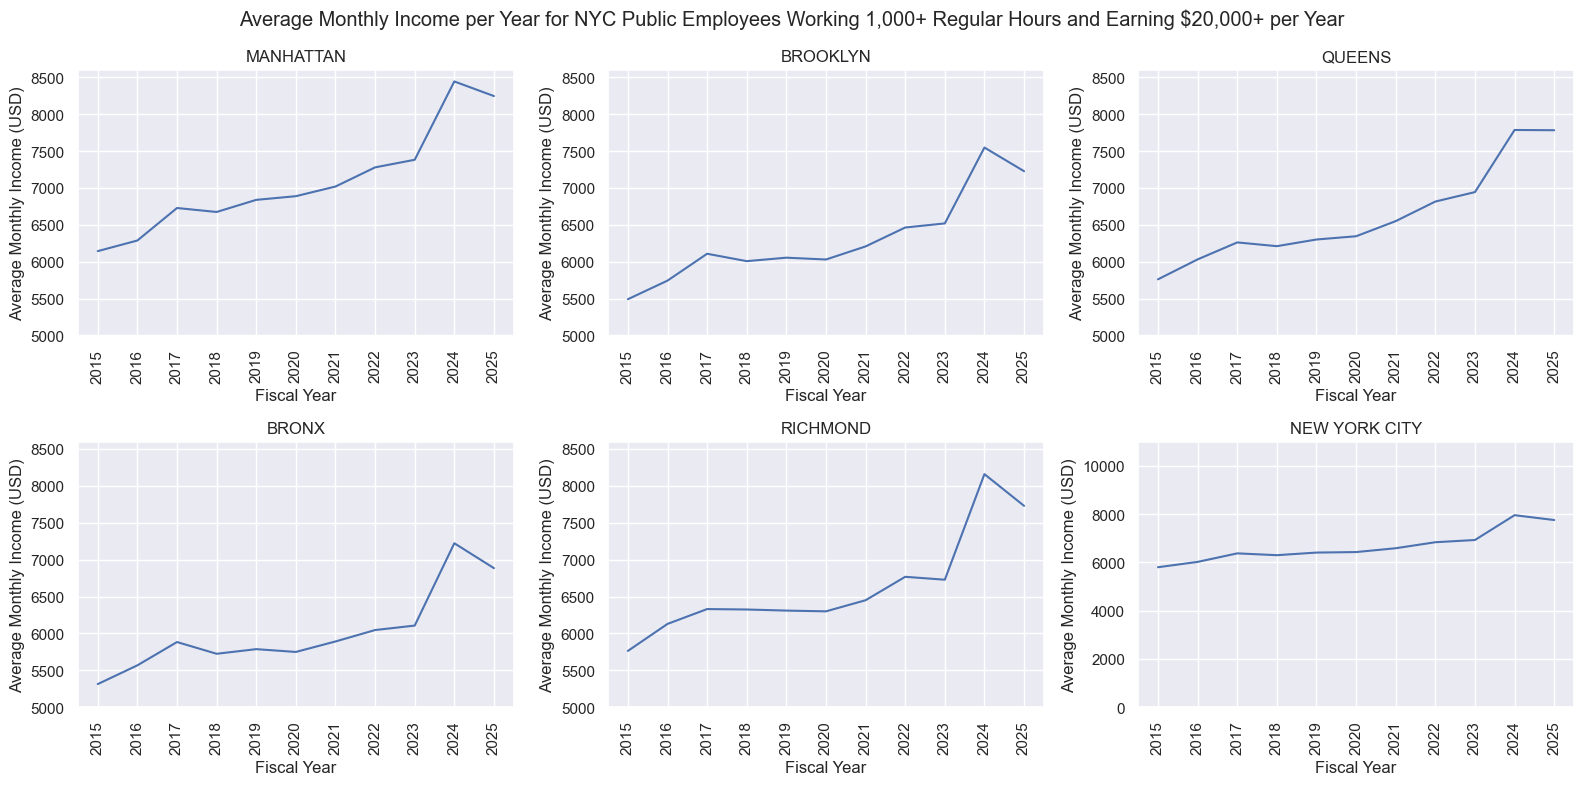

In [ ]:
same_y_lims = True

plt.figure(figsize=(16, 8))

for i, borough in enumerate(cwpd["Work Location Borough"].unique()):
    plt.subplot(2, 3, i+1)
    plt.plot(cwpd["Fiscal Year"].unique()[10::-1],
            cwpd[(cwpd["Work Location Borough"] == borough) & 
                 (cwpd["Fiscal Year"] > 2014) & 
                 (cwpd["Regular Hours"] > 1000) &
                 (cwpd["Annual Salary Estimate"] > 20000)][["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean()['Annual Salary Estimate'] / 12)
    plt.title(borough)
    plt.xticks(cwpd["Fiscal Year"].unique()[10::-1], rotation='vertical')
    plt.ylabel("Average Monthly Income (USD)")
    plt.xlabel("Fiscal Year")
    if same_y_lims:
        plt.ylim(5000, 8600)

plt.subplot(2, 3, 6)
plt.plot(cwpd["Fiscal Year"].unique()[10::-1], cwpd[(cwpd["Fiscal Year"] > 2014) & 
                                                   (cwpd["Regular Hours"] > 1000) &
                                                   (cwpd["Annual Salary Estimate"] > 20000)][["Fiscal Year", "Annual Salary Estimate"]].groupby("Fiscal Year").mean()['Annual Salary Estimate'] / 12)
plt.xticks(cwpd["Fiscal Year"].unique()[10::-1], rotation='vertical')
plt.title("NEW YORK CITY")
plt.ylabel("Average Monthly Income (USD)")
plt.xlabel("Fiscal Year")
plt.ylim(0, 11000)

plt.suptitle("Average Monthly Income per Year for NYC Public Employees Working 1,000+ Regular Hours and Earning $20,000+ per Year")
plt.tight_layout()
plt.show()

In [ ]:
cwpd[['Pay Basis', 'Hourly Rate']].groupby('Pay Basis').describe()

Hourly Rate                                              \
                      count       mean         std       min        25%   
Pay Basis                                                                 
Prorated Annual     24352.0  22.828985   16.567371  0.000014  18.074279   
per Annum         2084516.0  43.188110   83.769835  0.000013  25.058268   
per Day            161100.0  75.467407   95.156988  0.000018  40.865313   
per Hour           332498.0  40.324806  539.794667  0.004066  15.000000   

                                                     
                       50%        75%           max  
Pay Basis                                            
Prorated Annual  19.679688  23.167195   1641.857143  
per Annum        36.529216  46.907088  57703.692308  
per Day          51.498521  76.666956  12429.645714  
per Hour         17.746650  30.069406  57113.700000

In [ ]:
cwpd[cwpd["Pay Basis"] == "Prorated Annual"]

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay,Hourly Rate,Annual Salary Estimate
530448,2022,13.0,BOROUGH PRESIDENT-QUEENS,ZHAO,MING,NaN,06/15/2008,QUEENS,CASHIER,CEASED,35473.0,Prorated Annual,990.00,22041.83,0.0,0.0,198.45,22.264475,46310.107475
530549,2021,13.0,BOROUGH PRESIDENT-QUEENS,ZHAO,MING,NaN,06/15/2008,QUEENS,CASHIER,ACTIVE,35473.0,Prorated Annual,1560.00,35373.21,0.0,0.0,0.00,22.675135,47164.280000
530647,2020,13.0,BOROUGH PRESIDENT-QUEENS,ZHAO,MING,NaN,06/15/2008,QUEENS,CASHIER,ACTIVE,35473.0,Prorated Annual,1560.00,34249.98,0.0,0.0,0.00,21.955115,45666.640000
530660,2019,13.0,BOROUGH PRESIDENT-QUEENS,SOLARSH,ROXANNE,NaN,01/08/2008,QUEENS,COMMUNITY ASSISTANT,CEASED,20757.0,Prorated Annual,193.00,4346.65,0.0,0.0,206.52,22.521503,46844.725389
530671,2019,13.0,BOROUGH PRESIDENT-QUEENS,ZHAO,MING,NaN,06/15/2008,QUEENS,CASHIER,ACTIVE,34440.0,Prorated Annual,1564.28,34640.43,0.0,0.0,0.00,22.144648,46060.867875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6755989,2016,NaN,TAX COMMISSION,ALVAREZ,JANET,NaN,12/02/2015,MANHATTAN,COMMISSIONER,ACTIVE,25677.0,Prorated Annual,757.13,13540.05,0.0,0.0,0.00,17.883389,37197.448259
6755996,2016,NaN,TAX COMMISSION,STABILE,RICHARD,A,05/17/2004,BRONX,COMMISSIONER,ACTIVE,25677.0,Prorated Annual,1307.13,25539.94,0.0,0.0,0.00,19.538944,40641.003726
6756027,2015,NaN,TAX COMMISSION,GROSSMAN,SUSAN,NaN,03/01/2005,BRONX,COMMISSIONER,ACTIVE,25677.0,Prorated Annual,1303.57,25606.63,0.0,0.0,0.00,19.643464,40858.404535
6756053,2015,NaN,TAX COMMISSION,STABILE,RICHARD,A,05/17/2004,BRONX,COMMISSIONER,ACTIVE,25677.0,Prorated Annual,1303.57,25606.63,0.0,0.0,0.00,19.643464,40858.404535


In [ ]:
cwpd[cwpd["Regular Hours"] == 0]

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
36,2025,67.0,ADMIN FOR CHILDREN'S SVCS,ROSENBLUM,RANDI,F,09/16/2019,MANHATTAN,DIRECTOR OF FIELD OPERATIONS,CEASED,136289.0,per Annum,0.0,2664.03,0.0,0.00,0.00
124,2025,67.0,ADMIN FOR CHILDREN'S SVCS,ALLEYNE,KENYA,M,08/04/2014,MANHATTAN,CHILD PROTECTIVE SPECIALIST,ON LEAVE,70106.0,per Annum,0.0,37.83,0.0,0.00,2528.53
160,2025,67.0,ADMIN FOR CHILDREN'S SVCS,BROBBEY,EUGENE,NaN,03/15/2021,BRONX,YOUTH DEVELOPMENT SPECIALIST,CEASED,48545.0,per Annum,0.0,52.66,0.0,0.00,0.00
192,2025,67.0,ADMIN FOR CHILDREN'S SVCS,BIBILONI,CARLOS,M,01/11/2021,BRONX,YOUTH DEVELOPMENT SPECIALIST,CEASED,52320.0,per Annum,0.0,1646.07,3.5,98.94,49.91
218,2025,67.0,ADMIN FOR CHILDREN'S SVCS,WELLS,MARC,L,02/25/2019,BRONX,YOUTH DEVELOPMENT SPECIALIST,CEASED,57779.0,per Annum,0.0,4189.68,0.0,0.00,64.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775813,2023,858.0,TECHNOLOGY & INNOVATION,TUNKARA,YUSUPHA,NaN,12/31/2018,BROOKLYN,CERTIFIED IT ADMINISTRATOR,CEASED,116699.0,per Annum,0.0,2423.68,0.0,0.00,450.96
6775820,2023,858.0,TECHNOLOGY & INNOVATION,TRIVEDI,FALGUNI,K,12/14/2015,BROOKLYN,COMPUTER SPECIALIST,CEASED,132613.0,per Annum,0.0,1355.03,0.0,0.00,451.69
6775821,2023,858.0,TECHNOLOGY & INNOVATION,TRINIDAD,KATHLEEN,P,08/02/2021,MANHATTAN,CALL CENTER REPRESENTATIVE,CEASED,36135.0,per Annum,0.0,40.35,0.0,0.00,0.00
6775822,2023,858.0,TECHNOLOGY & INNOVATION,TRAMBADIA,AMIT,G,06/04/2018,BROOKLYN,CERTIFIED IT DEVELOPER,CEASED,119324.0,per Annum,0.0,2503.96,0.0,0.00,137.01


In [ ]:
cwpd[(cwpd["Base Salary"] < 40000) &
     (cwpd["Pay Basis"] == "per Annum")]

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
237,2025,67.0,ADMIN FOR CHILDREN'S SVCS,HAZEL,TAYVIUS,D,06/03/2024,BRONX,SPECIAL OFFICER,CEASED,36955.0,per Annum,29.47,334.37,4.25,95.13,0.00
775,2025,67.0,ADMIN FOR CHILDREN'S SVCS,PLANAS,JACQUELINE,J,08/14/2023,BROOKLYN,SPECIAL OFFICER,CEASED,36955.0,per Annum,0.00,40.55,0.00,0.00,0.00
1106,2025,67.0,ADMIN FOR CHILDREN'S SVCS,ARJOON,RAVIN,D,10/07/2024,MANHATTAN,SPECIAL OFFICER,ACTIVE,39206.0,per Annum,1440.00,26436.25,118.25,3299.98,2561.46
1368,2025,67.0,ADMIN FOR CHILDREN'S SVCS,SUGGS,LASHEA,D,03/11/2024,MANHATTAN,SPECIAL OFFICER,ACTIVE,39206.0,per Annum,2080.00,37637.87,135.50,3789.14,7100.06
1540,2025,67.0,ADMIN FOR CHILDREN'S SVCS,JOHNSON,BRIAN,L,10/07/2024,BROOKLYN,SPECIAL OFFICER,ACTIVE,39206.0,per Annum,1440.00,26212.87,296.75,8294.27,3829.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775777,2023,858.0,TECHNOLOGY & INNOVATION,VELEZ,JANET,NaN,11/15/2021,MANHATTAN,CALL CENTER REPRESENTATIVE,CEASED,36135.0,per Annum,0.00,60.53,0.00,0.00,0.00
6775784,2023,858.0,TECHNOLOGY & INNOVATION,VASCONCELLOS-GA,RHONDA,L,08/29/2022,MANHATTAN,CALL CENTER REPRESENTATIVE,ACTIVE,38336.0,per Annum,1470.00,29875.87,0.00,0.00,3358.64
6775798,2023,858.0,TECHNOLOGY & INNOVATION,VALENTIN,RICARDO,NaN,05/06/2004,BROOKLYN,COMMUNITY ASSISTANT,CEASED,38607.0,per Annum,0.00,386.92,0.00,0.00,6.42
6775799,2023,858.0,TECHNOLOGY & INNOVATION,VAKIL,SHWETAL,B,01/23/2023,MANHATTAN,CALL CENTER REPRESENTATIVE,CEASED,37219.0,per Annum,70.00,428.17,0.00,0.00,403.68


In [ ]:
cwpd[cwpd["Regular Hours"] < 0]

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay


In [ ]:
cwpd[cwpd["Regular Gross Paid"] < 0]

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
